# Experimento 3 — Técnicas de Time Warping Temporales

Evalúa el impacto de las técnicas de time warping extremas sobre las tres herramientas de anotación.

**Hipótesis:** Las técnicas `very_slow (0.5×)`, `very_fast (1.5×)` y `frame_drop` pueden introducir artefactos que perjudican la generalización, especialmente en CVAT y ELAN.

| Versión | Técnicas | Descripción |
|:-------:|:--------:|:------------|
| v1      | 9        | Base del experimento A/B |
| v2b     | 12       | v1 + translate, fast_flip, rot_noise (sin temporales extremas) |
| v2      | 15       | v2b + very_slow, very_fast, frame_drop |

**Prerequisito:** `09_aumentar_datos.py`, `07_extraer_keypoints.py` y `exp1_ab_pipeline.py` ejecutados.

In [1]:
import os
import sys
import random
import numpy as np
import tensorflow as tf
import pandas as pd
from pathlib import Path
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

# Semilla fija: garantiza que las 3 versiones sean reproducibles entre corridas
# (init de pesos y barajado del entrenamiento dejan de ser aleatorios).
SEED = 42

def fijar_semilla(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

fijar_semilla()

sys.path.insert(0, str(Path(os.getcwd()).parent.parent))
from utils.config import (N_FRAMES, N_KEYPOINTS, DATA_DIR, SPLIT_PATH,
                           CSV_TOP35, KEYPOINTS_DIR)
from utils.preprocessing import normalizar_hombros
from utils.model import construir_lstm, callbacks_entrenamiento
from utils.data_io import cargar_herramienta_comparativa

SALIDA_DIR = os.path.join(DATA_DIR, "experimentos", "exp3_tecnicas")
os.makedirs(SALIDA_DIR, exist_ok=True)

# Dataset de aumento con las 15 técnicas (exclusivo del experimento; el de
# producción dataset_aumentado_v2.csv solo tiene las 9 finales). Generarlo con
# experimentos/exp3_tecnicas/generar_aumento_15tecnicas.py antes de correr esta notebook.
CSV_AUG_15 = os.path.join(SALIDA_DIR, "dataset_aumentado_15tecnicas.csv")

TECNICAS_V1  = {'flip', 'slow', 'fast', 'noise', 'rot_pos', 'rot_neg',
                'scale', 'flip_noise', 'slow_noise'}
TECNICAS_V2B = TECNICAS_V1 | {'translate', 'fast_flip', 'rot_noise'}
TECNICAS_V2  = TECNICAS_V2B | {'very_slow', 'very_fast', 'frame_drop'}

print(f"Directorio de salida: {SALIDA_DIR}")
print(f"v1: {len(TECNICAS_V1)} técnicas | v2b: {len(TECNICAS_V2B)} | v2: {len(TECNICAS_V2)}")

Directorio de salida: C:\Users\dell\Documents\TIC\Codigo_TIC\experimentos\exp3_tecnicas
v1: 9 técnicas | v2b: 12 | v2: 15


## Carga de datos base

In [2]:
def cargar_base():
    df      = pd.read_csv(CSV_TOP35)
    clases  = sorted(df['glosa'].unique())
    idx_map = {c: i for i, c in enumerate(clases)}
    X, y, ids = [], [], []
    for _, row in df.iterrows():
        npy = os.path.join(KEYPOINTS_DIR, f"{row['video_id']}.npy")
        if not os.path.exists(npy): continue
        kp = np.load(npy)
        if kp.shape != (N_FRAMES, N_KEYPOINTS): continue
        X.append(kp); y.append(idx_map[row['glosa']]); ids.append(row['video_id'])
    return (np.array(X, dtype=np.float32), np.array(y, dtype=np.int32), ids, clases, idx_map)

X_all, y_all, video_ids, clases, idx_map = cargar_base()
n_clases = len(clases)

split     = np.load(SPLIT_PATH, allow_pickle=True)
idx_train = split['idx_train'].tolist()
idx_val   = split['idx_val'].tolist()
idx_test  = split['idx_test'].tolist()
train_ids = {video_ids[i] for i in idx_train}

X_ls   = np.array([normalizar_hombros(X_all[i]) for i in idx_test], dtype=np.float32)
y_ls   = y_all[idx_test]
X_val  = np.array([normalizar_hombros(X_all[i]) for i in idx_val],  dtype=np.float32)
y_val  = y_all[idx_val]
X_orig = np.array([normalizar_hombros(X_all[i]) for i in idx_train], dtype=np.float32)
y_orig = y_all[idx_train]

X_cvat, y_cvat = cargar_herramienta_comparativa("cvat", idx_map)
X_elan, y_elan = cargar_herramienta_comparativa("elan", idx_map)
print(f"LS test: {len(X_ls)} | CVAT: {len(X_cvat)} | ELAN: {len(X_elan)}")

LS test: 35 | CVAT: 34 | ELAN: 34


## Cargar dataset aumentado v2

In [3]:
if not os.path.exists(CSV_AUG_15):
    raise FileNotFoundError(f"[ERROR] Ejecuta experimentos/exp3_tecnicas/generar_aumento_15tecnicas.py primero\nBuscado: {CSV_AUG_15}")

df_aug = pd.read_csv(CSV_AUG_15)
df_aug = df_aug[
    (df_aug['tipo'] != 'original') &
    (df_aug['original'].isin(train_ids)) &
    (df_aug['glosa'].isin(clases))
].copy()
df_aug['clase_idx'] = df_aug['glosa'].map(idx_map)
print(f"Dataset aumentado cargado: {len(df_aug)} muestras")
print(f"Tipos disponibles: {sorted(df_aug['tipo'].unique())}")

Dataset aumentado cargado: 1245 muestras
Tipos disponibles: ['fast', 'fast_flip', 'flip', 'flip_noise', 'frame_drop', 'noise', 'rot_neg', 'rot_noise', 'rot_pos', 'scale', 'slow', 'slow_noise', 'translate', 'very_fast', 'very_slow']


## Funciones de construcción y entrenamiento

In [4]:
def construir_train(df_aug, tecnicas, train_ids, X_orig, y_orig):
    df_f = df_aug[df_aug['tipo'].isin(tecnicas)]
    X_aug, y_aug = [], []
    for _, row in df_f.iterrows():
        if not os.path.exists(row['npy_path']): continue
        kp = np.load(row['npy_path'])
        if kp.shape != (N_FRAMES, N_KEYPOINTS): continue
        X_aug.append(kp); y_aug.append(int(row['clase_idx']))
    return (np.concatenate([X_orig, np.array(X_aug, dtype=np.float32)]),
            np.concatenate([y_orig, np.array(y_aug, dtype=np.int32)]))

def entrenar_y_evaluar(nombre, X_tr, y_tr, X_val, y_val,
                        X_ls, y_ls, X_cvat, y_cvat, X_elan, y_elan,
                        n_clases, clave):
    print(f"\n{'='*55}\n{nombre}  (train={len(X_tr)})\n{'='*55}")
    fijar_semilla()   # mismo punto de partida para cada versión → reproducible
    model = construir_lstm(n_clases, lr=0.001, dropout=0.5,
                            regularizacion=0.005, capa_densa=False)
    ruta = os.path.join(SALIDA_DIR, f'modelo_{clave}.keras')
    hist = model.fit(X_tr, to_categorical(y_tr, n_clases),
                     validation_data=(X_val, to_categorical(y_val, n_clases)),
                     epochs=100, batch_size=32,
                     callbacks=callbacks_entrenamiento(ruta, patience_stop=20, patience_lr=7),
                     verbose=1)
    h       = hist.history
    acc_key = 'accuracy' if 'accuracy' in h else 'categorical_accuracy'
    np.save(os.path.join(SALIDA_DIR, f'historial_{clave}.npy'), h)

    acc  = lambda X, y: accuracy_score(y, np.argmax(model.predict(X, verbose=0), axis=1))
    ls   = acc(X_ls, y_ls)
    cvat = acc(X_cvat, y_cvat) if len(X_cvat) > 0 else None
    elan = acc(X_elan, y_elan) if len(X_elan) > 0 else None
    val  = max(h['val_accuracy'])
    ep   = len(h[acc_key])

    print(f"  LS: {ls*100:.1f}%"
          + (f"  CVAT: {cvat*100:.1f}%" if cvat is not None else "  CVAT: N/A")
          + (f"  ELAN: {elan*100:.1f}%" if elan is not None else "  ELAN: N/A"))
    return ls, cvat, elan, val, ep, len(X_tr)

## Entrenamiento v1 (9 técnicas)

In [5]:
X_tr_v1, y_tr_v1 = construir_train(df_aug, TECNICAS_V1, train_ids, X_orig, y_orig)
ls_v1, cvat_v1, elan_v1, val_v1, ep_v1, n_v1 = entrenar_y_evaluar(
    'v1  (9 técnicas — base)', X_tr_v1, y_tr_v1, X_val, y_val,
    X_ls, y_ls, X_cvat, y_cvat, X_elan, y_elan, n_clases, 'v1')


v1  (9 técnicas — base)  (train=830)


Epoch 1/100


 1/26 [>.............................] - ETA: 1:49 - loss: 5.7619 - accuracy: 0.1250

 3/26 [==>...........................] - ETA: 0s - loss: 5.8639 - accuracy: 0.0625  

 5/26 [====>.........................] - ETA: 0s - loss: 5.7744 - accuracy: 0.0375

...

25/26 [===========================>..] - ETA: 0s - loss: 0.9460 - accuracy: 0.9362

Restoring model weights from the end of the best epoch: 12.


26/26 [==============================] - 1s 34ms/step - loss: 0.9448 - accuracy: 0.9386 - val_loss: 3.4941 - val_accuracy: 0.4000 - lr: 2.5000e-04


Epoch 32: early stopping


  LS: 34.3%  CVAT: 23.5%  ELAN: 14.7%


## Entrenamiento v2b (12 técnicas, sin temporales extremas)

In [6]:
X_tr_v2b, y_tr_v2b = construir_train(df_aug, TECNICAS_V2B, train_ids, X_orig, y_orig)
ls_v2b, cvat_v2b, elan_v2b, val_v2b, ep_v2b, n_v2b = entrenar_y_evaluar(
    'v2b (12 técnicas — sin temporales)', X_tr_v2b, y_tr_v2b, X_val, y_val,
    X_ls, y_ls, X_cvat, y_cvat, X_elan, y_elan, n_clases, 'v2b')


v2b (12 técnicas — sin temporales)  (train=1079)


Epoch 1/100


 1/34 [..............................] - ETA: 2:10 - loss: 6.0842 - accuracy: 0.0000e+00

 3/34 [=>............................] - ETA: 0s - loss: 6.0021 - accuracy: 0.0000e+00  

 5/34 [===>..........................] - ETA: 0s - loss: 5.8678 - accuracy: 0.0063    

...

33/34 [============================>.] - ETA: 0s - loss: 0.4558 - accuracy: 0.9830

Restoring model weights from the end of the best epoch: 21.


34/34 [==============================] - 1s 29ms/step - loss: 0.4561 - accuracy: 0.9824 - val_loss: 3.6887 - val_accuracy: 0.4000 - lr: 2.5000e-04


Epoch 41: early stopping


  LS: 48.6%  CVAT: 41.2%  ELAN: 23.5%


## Entrenamiento v2 (15 técnicas, con temporales extremas)

In [7]:
X_tr_v2, y_tr_v2 = construir_train(df_aug, TECNICAS_V2, train_ids, X_orig, y_orig)
ls_v2, cvat_v2, elan_v2, val_v2, ep_v2, n_v2 = entrenar_y_evaluar(
    'v2  (15 técnicas — con temporales)', X_tr_v2, y_tr_v2, X_val, y_val,
    X_ls, y_ls, X_cvat, y_cvat, X_elan, y_elan, n_clases, 'v2')


v2  (15 técnicas — con temporales)  (train=1328)


Epoch 1/100


 1/42 [..............................] - ETA: 2:15 - loss: 5.6240 - accuracy: 0.0312

 3/42 [=>............................] - ETA: 1s - loss: 5.7944 - accuracy: 0.0312  

 5/42 [==>...........................] - ETA: 1s - loss: 5.6447 - accuracy: 0.0312

...

41/42 [============================>.] - ETA: 0s - loss: 0.4466 - accuracy: 0.9863

Restoring model weights from the end of the best epoch: 15.


42/42 [==============================] - 2s 39ms/step - loss: 0.4474 - accuracy: 0.9857 - val_loss: 3.7508 - val_accuracy: 0.4000 - lr: 2.5000e-04


Epoch 35: early stopping


  LS: 42.9%  CVAT: 32.4%  ELAN: 20.6%


## Diagnóstico y resultados finales

In [8]:
def pct(v):
    return f"{v*100:.1f} %".replace(".", ",") if v is not None else "N/A"

resultados = [
    {'version': 'v1  (9 técnicas — base)',            'n_tecnicas': len(TECNICAS_V1),
     'temporales_extremas': False, 'muestras_train': n_v1,
     'val_acc': val_v1, 'epocas': ep_v1,
     'acc_label_studio': ls_v1, 'acc_cvat': cvat_v1, 'acc_elan': elan_v1},
    {'version': 'v2b (12 técnicas — sin temporales)', 'n_tecnicas': len(TECNICAS_V2B),
     'temporales_extremas': False, 'muestras_train': n_v2b,
     'val_acc': val_v2b, 'epocas': ep_v2b,
     'acc_label_studio': ls_v2b, 'acc_cvat': cvat_v2b, 'acc_elan': elan_v2b},
    {'version': 'v2  (15 técnicas — con temporales)', 'n_tecnicas': len(TECNICAS_V2),
     'temporales_extremas': True,  'muestras_train': n_v2,
     'val_acc': val_v2, 'epocas': ep_v2,
     'acc_label_studio': ls_v2, 'acc_cvat': cvat_v2, 'acc_elan': elan_v2},
]

# Tabla limpia en % impresa en el mismo paso (lista para captura)
print("="*74)
print("  EXACTITUD POR VERSIÓN DE AUMENTO")
print("="*74)
print(f"  {'Versión':<38}{'Label Studio':>12}{'CVAT':>10}{'ELAN':>10}")
print("  " + "-"*70)
for x in resultados:
    print(f"  {x['version']:<38}{pct(x['acc_label_studio']):>12}"
          f"{pct(x['acc_cvat']):>10}{pct(x['acc_elan']):>10}")
print("="*74)

# Guardar CSV con valores numéricos (para las figuras/regeneración)
df_res = pd.DataFrame(resultados)
df_res.to_csv(os.path.join(SALIDA_DIR, 'resultados_tecnicas_temporales.csv'),
              index=False, encoding='utf-8-sig')
print(f"\nResultados guardados en: {SALIDA_DIR}")

# DataFrame formateado en % para mostrar como tabla en la notebook
df_pct = df_res.copy()
for c in ['val_acc', 'acc_label_studio', 'acc_cvat', 'acc_elan']:
    df_pct[c] = df_pct[c].apply(pct)
df_pct

  EXACTITUD POR VERSIÓN DE AUMENTO
  Versión                               Label Studio      CVAT      ELAN
  ----------------------------------------------------------------------
  v1  (9 técnicas — base)                     34,3 %    23,5 %    14,7 %
  v2b (12 técnicas — sin temporales)          48,6 %    41,2 %    23,5 %
  v2  (15 técnicas — con temporales)          42,9 %    32,4 %    20,6 %

Resultados guardados en: C:\Users\dell\Documents\TIC\Codigo_TIC\experimentos\exp3_tecnicas


,version,n_tecnicas,temporales_extremas,muestras_train,val_acc,epocas,acc_label_studio,acc_cvat,acc_elan
0,v1 (9 técnicas — base),9,False,830,"40,0 %",32,"34,3 %","23,5 %","14,7 %"
1,v2b (12 técnicas — sin temporales),12,False,1079,"42,9 %",41,"48,6 %","41,2 %","23,5 %"
2,v2 (15 técnicas — con temporales),15,True,1328,"48,6 %",35,"42,9 %","32,4 %","20,6 %"


## Visualización

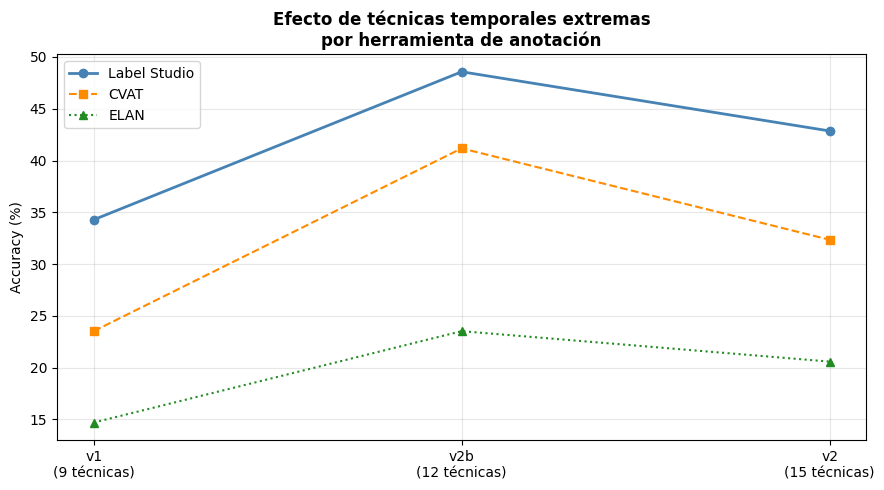

In [9]:
import matplotlib.pyplot as plt

versiones = ['v1\n(9 técnicas)', 'v2b\n(12 técnicas)', 'v2\n(15 técnicas)']
ls_vals   = [ls_v1*100,   ls_v2b*100,   ls_v2*100]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(versiones, ls_vals, 'o-', color='steelblue', label='Label Studio', linewidth=2)

if cvat_v1 is not None:
    ax.plot(versiones, [cvat_v1*100, cvat_v2b*100, cvat_v2*100],
            's--', color='darkorange', label='CVAT')
if elan_v1 is not None:
    ax.plot(versiones, [elan_v1*100, elan_v2b*100, elan_v2*100],
            '^:', color='forestgreen', label='ELAN')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Efecto de técnicas temporales extremas\npor herramienta de anotación', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SALIDA_DIR, 'tecnicas_temporales.png'), dpi=150)
plt.show()